In [1]:
%reload_ext autoreload
%autoreload 2

In [3]:
import sys
sys.path.append("..")

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# from utils.plot import plot_forecast

prices = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\imto_ts\data\shop_sales_prices.csv")
shop_sales = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales.csv")
shop_dates = pd.read_csv(r"C:\Users\makanov.artem\Desktop\ВР\data\shop_sales_dates.csv")

print(shop_sales.shape)

df = shop_sales.merge(shop_dates, on="date_id", how="left")
print(df.shape)
prices['store_id'] = prices['store_id'].map(lambda x: f"STORE_{x[-1:]}")
prices['item_id'] = prices['item_id'].map(lambda x: f"STORE_{x[3:]}")

df = df.merge(prices, on=['item_id', 'wm_yr_wk', 'store_id'], how='left')
print(df.shape)

df = df[df.store_id == 'STORE_1']
print(df.shape)

df.to_csv(r"C:\Users\makanov.artem\Desktop\ВР\imto_ts\data\df_raw.csv", index=False)

(81855, 4)
(81855, 17)
(81855, 18)
(27285, 18)


C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


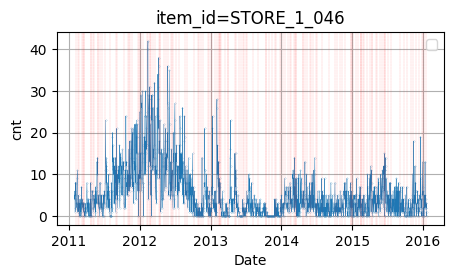

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


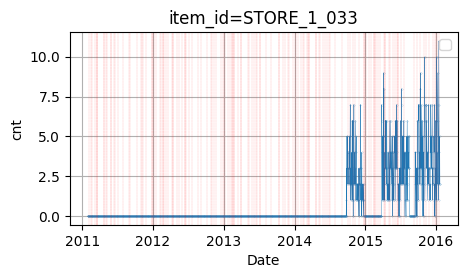

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


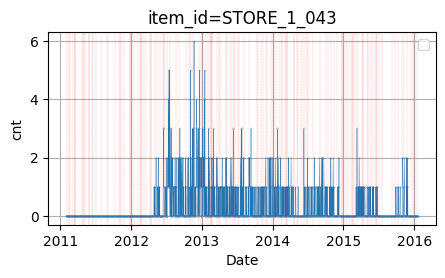

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


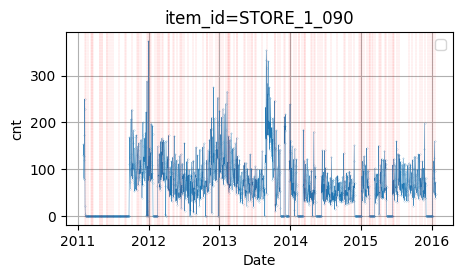

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


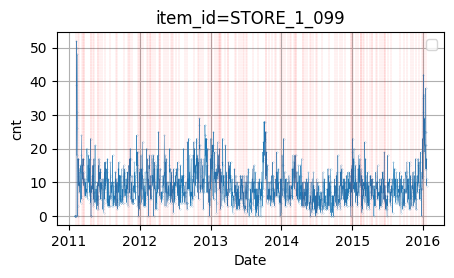

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


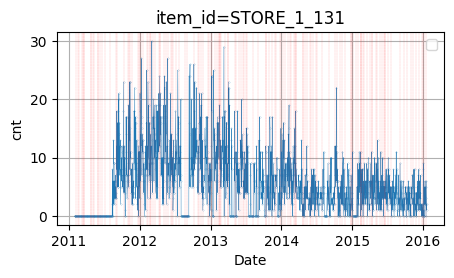

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


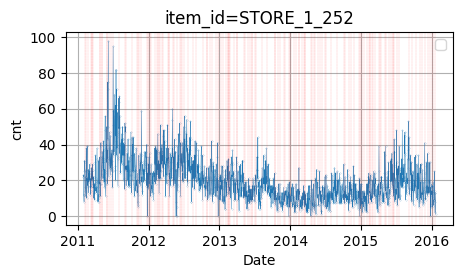

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


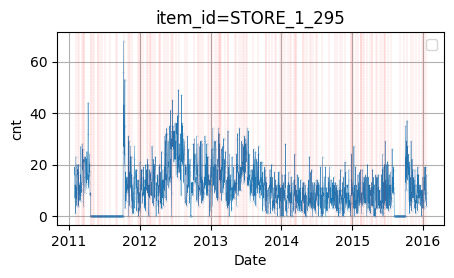

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


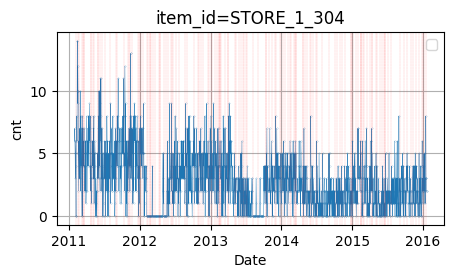

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


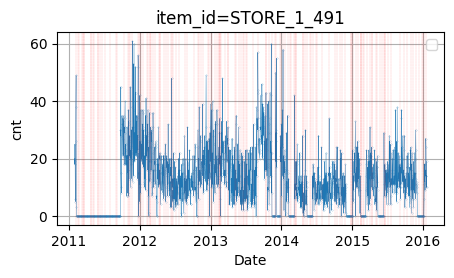

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


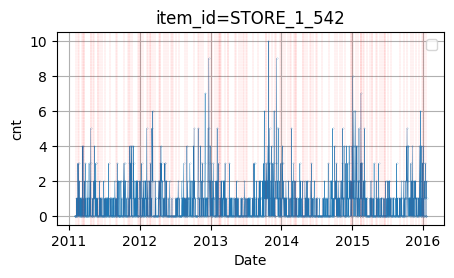

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


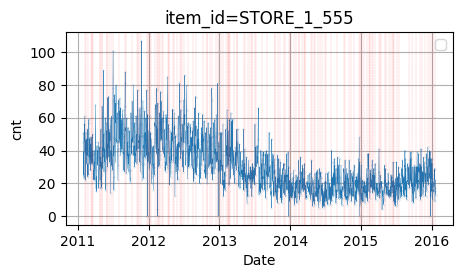

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


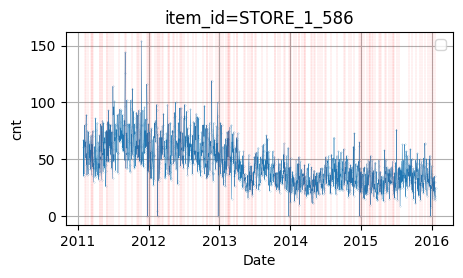

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


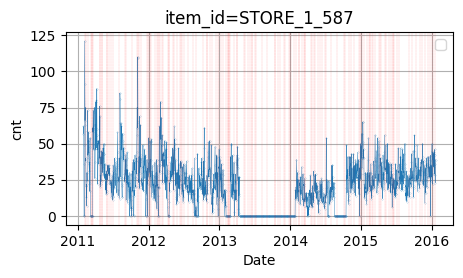

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\4237145649.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


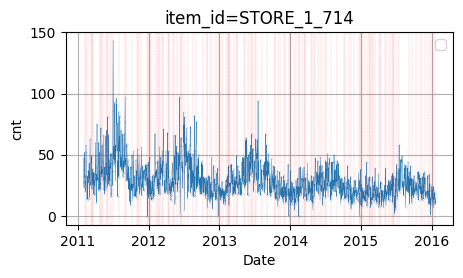

In [37]:
holiday_cols = ['event_name_1']
for item_id in df.item_id.unique().tolist():
    # реальные данные
    series = df[df['item_id'] == item_id].sort_values('date')

    # Приводим даты к pd.Timestamp
    dates = pd.to_datetime(series['date'])
    actual = series['cnt'].values

    # график
    plt.figure(figsize=(5,2.5))
    plt.plot(dates, actual, marker='o', markersize=0.1, linewidth=0.3)

    # # вертикальная линия
    for col in holiday_cols:
        for vline in series[~series[col].isna()].date:
            vline = pd.to_datetime(vline)
            plt.axvline(x=vline, color='red', linestyle='--', linewidth=0.1)

    plt.title(f"item_id={item_id}")
    plt.xlabel("Date")
    plt.ylabel("cnt")
    plt.legend()
    plt.grid(True)
    plt.show()


In [38]:
import pandas as pd
import numpy as np

def keep_longest_segment_with_zero_tolerance(s: pd.DataFrame, z: int = 1):
    """
    Оставляет самый длинный консистентный сегмент.
    Допускаются нули внутри сегмента, если их длина <= z.
    Нули длиной > z считаются разрывом.
    """

    s = s.copy().reset_index(drop=True)
    values = s['cnt'].values
    n = len(values)

    segments = []
    i = 0

    while i < n:
        # Найдём начало сегмента (ненулевое значение)
        if values[i] == 0:
            i += 1
            continue

        start = i
        j = i

        # Движемся вперёд, пока нули не превышают порог z
        zero_count = 0

        while j < n:
            if values[j] != 0:
                zero_count = 0
            else:
                zero_count += 1
                if zero_count > z:
                    break
            j += 1

        end = j - zero_count  # конец сегмента до большого разрыва
        segments.append((start, end, end - start))

        i = j  # продолжаем после разрыва

    # Если сегментов нет — вернуть пустой ряд
    if not segments:
        return s.iloc[0:0]

    result = s.iloc[start:end].reset_index(drop=True)

    # === Подрезаем правые нули ===
    while len(result) > 0 and result['cnt'].iloc[-1] == 0:
        result = result.iloc[:-1]


    

    return result.reset_index(drop=True)

In [39]:
item_id = 'STORE_1_043'
df_item = df[df.item_id == item_id]


In [40]:
print(df_item.shape)
cleaned = keep_longest_segment_with_zero_tolerance(df_item, z=15)
print(cleaned.shape)

(1819, 18)
(60, 18)


C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


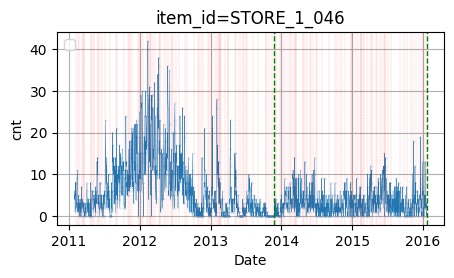

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


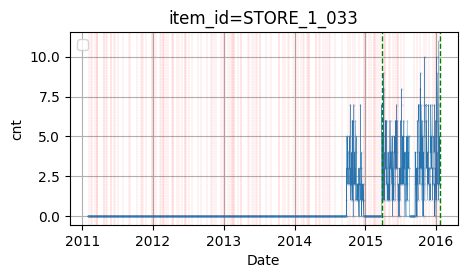

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


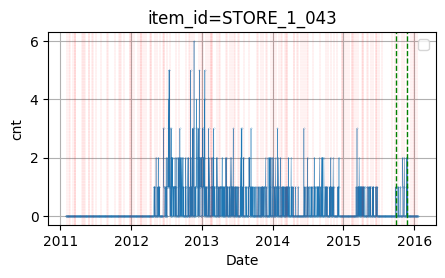

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


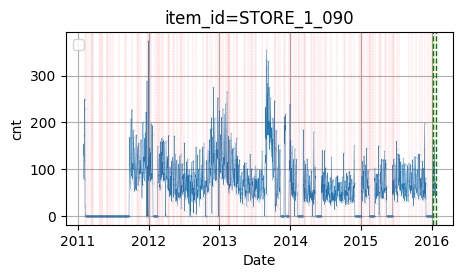

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


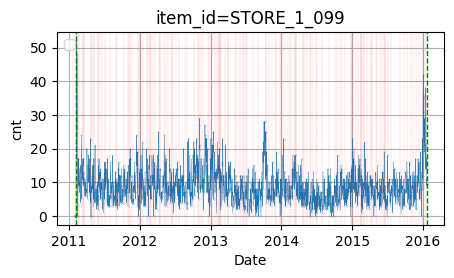

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


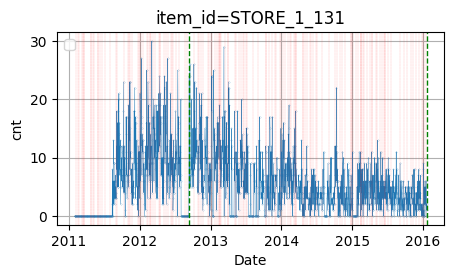

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


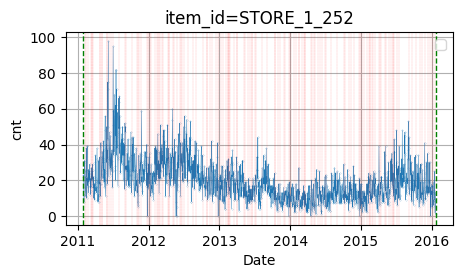

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


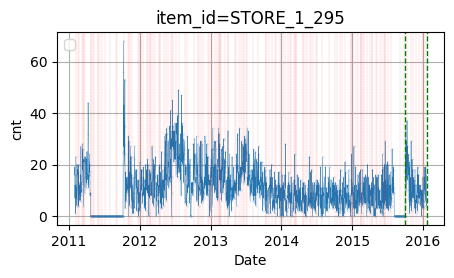

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


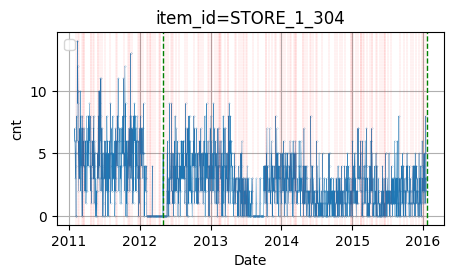

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


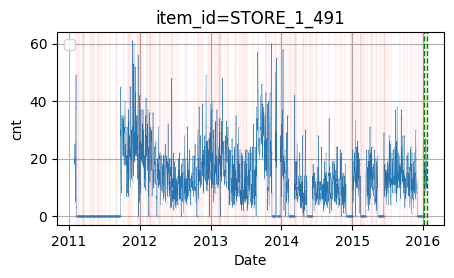

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


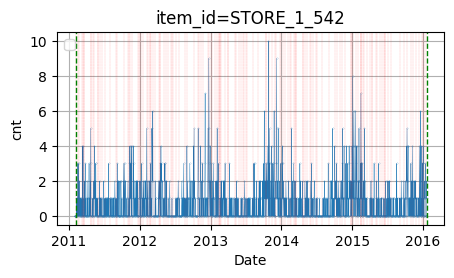

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


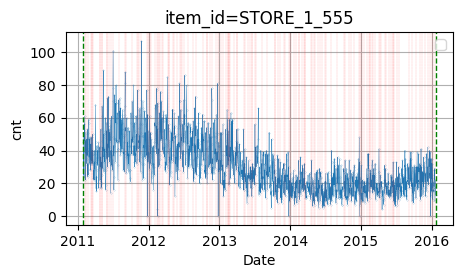

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


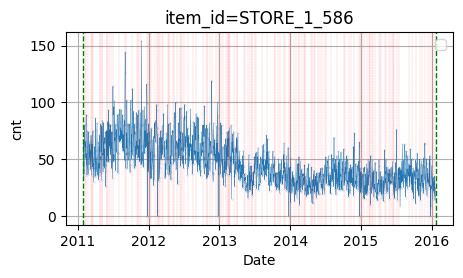

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


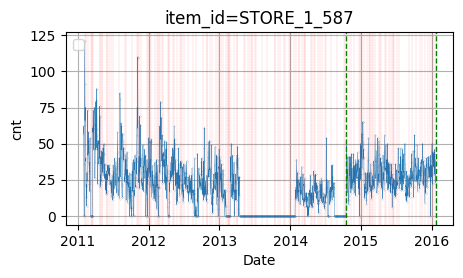

C:\Users\makanov.artem\AppData\Local\Temp\ipykernel_34288\1042456692.py:35: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


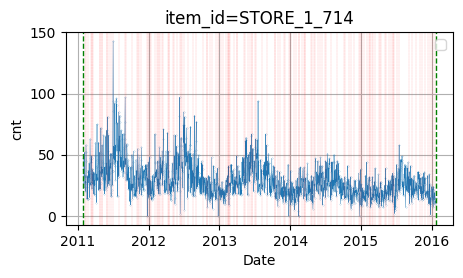

In [42]:
holiday_cols = ['event_name_1']
good_item_ids = []
good_dfs = []
for item_id in df.item_id.unique().tolist():

   
    series = df[df['item_id'] == item_id].sort_values('date')
    cleaned = keep_longest_segment_with_zero_tolerance(series, z=30)

    min_date, max_date = cleaned.date.min(), cleaned.date.max()
    min_date = pd.to_datetime(min_date)
    max_date = pd.to_datetime(max_date)

    # Приводим даты к pd.Timestamp
    dates = pd.to_datetime(series['date'])
    actual = series['cnt'].values

    # график
    plt.figure(figsize=(5,2.5))
    plt.plot(dates, actual, marker='o', markersize=0.1, linewidth=0.3)

    # # вертикальная линия
    for col in holiday_cols:
        for vline in series[~series[col].isna()].date:
            vline = pd.to_datetime(vline)
            plt.axvline(x=vline, color='red', linestyle='--', linewidth=0.1)


    plt.axvline(x=min_date, color='green', linestyle='--', linewidth=1.)
    plt.axvline(x=max_date, color='green', linestyle='--', linewidth=1.)

    plt.title(f"item_id={item_id}")
    plt.xlabel("Date")
    plt.ylabel("cnt")
    plt.legend()
    plt.grid(True)
    plt.show()

    if max_date - min_date >= pd.Timedelta(days=365):
        good_item_ids.append(item_id)
        good_dfs.append(cleaned)


In [43]:
len(good_item_ids)

10

In [46]:
pd.concat(good_dfs).to_csv(r'C:\Users\makanov.artem\Desktop\ВР\imto_ts\data\df.csv')